# Inference Testing Notebook
Here I will test out various data manipulation and visualization techniques on the song embeddings to see what insights I can glean about global music trends. This is a sandbox for trying out different approaches before I finalize the analysis for the paper.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin_min
import umap
import plotly.express as px

# Load your processed data
df = pd.read_pickle('all_songs_embeddings.pkl')

# Convert the 'embedding' column into a 2D numpy matrix for math operations
X = np.stack(df['embedding'].values)

print(f"Successfully loaded {len(df)} songs with {X.shape[1]} dimensions.")
print(df.columns)

/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully loaded 23416 songs with 384 dimensions.
Index(['Unnamed: 0_x', 'track.id', 'lyrics', 'Unnamed: 0_y', 'playlist.id',
       'playlist.name', 'track.name', 'track.popularity', 'added_date',
       'playlist.track.extracteddate', 'embedding'],
      dtype='str')


# **Inference from k-means clustering**

## Find Optimal K with Elbow Method

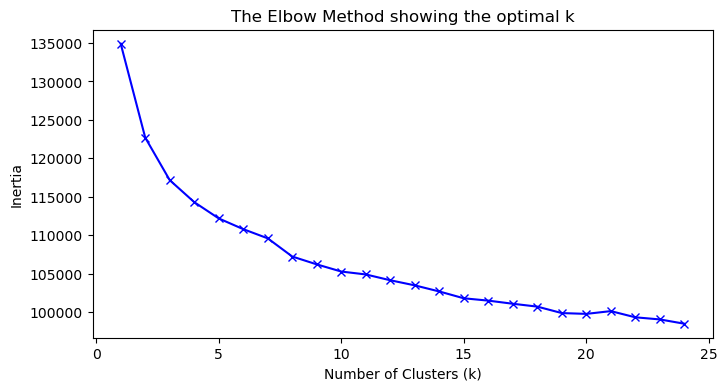

In [2]:
inertia = []
K_range = range(1, 25)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()

## K-means Clustering on the Meaning Map

In [3]:
# Finding N distinct 'meaning' groups
n_clusters = 6

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X)


In [4]:
# We use 'cosine' metric because embeddings are directional vectors
reducer = umap.UMAP(
    n_neighbors=n_clusters , 
    min_dist=0.1, 
    metric='cosine', 
    random_state=42
)

# This creates your 2D coordinates
embedding_2d = reducer.fit_transform(X)
df['x'], df['y'] = embedding_2d[:, 0], embedding_2d[:, 1]


/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/keionvergara/miniforge3/envs/MMIL/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is like

In [14]:

fig = px.scatter(
    df, x='x', y='y',
    color=df['cluster_label'].astype(str),
    hover_data=['playlist.name', 'track.name'],
    title=f"Discovery of Lyric Themes (K-Means) with {n_clusters} Clusters",
    template='plotly_dark'
)
fig.show()

## Domination Analysis: Which countries dominate which clusters?

In [5]:


# 1. Find the 'Mascot' for each cluster (The most central song)
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
df['is_representative'] = False

# for i, idx in enumerate(closest):
#     print(f"\n--- CLUSTER {i} REPRESENTATIVE ---")
#     rep_song = df.iloc[idx]
#     print(f"Song: {rep_song['track.name']} | Country/Playlist: {rep_song['playlist.name']}")
#     print(f"Lyrics Snippet: {rep_song['lyrics'][:150]}...")

# 2. Identify Country Dominance in Clusters
# This is where your 'Diverse Voices' inference lives
cluster_geo = pd.crosstab(df['cluster_label'], df['playlist.name'], normalize='index') * 100

print("\n--- GEOGRAPHIC DOMINANCE ---")
for i in range(n_clusters):
    top_country = cluster_geo.loc[i].idxmax()
    percentage = cluster_geo.loc[i].max()
    print(f"Cluster {i} is dominated by {top_country} ({percentage:.1f}%)")


--- GEOGRAPHIC DOMINANCE ---
Cluster 0 is dominated by Top 50 - Hong Kong (6.3%)
Cluster 1 is dominated by Top 50 - Morocco (48.8%)
Cluster 2 is dominated by Top 50 - Indonesia (3.6%)
Cluster 3 is dominated by Top 50 - Greece (4.9%)
Cluster 4 is dominated by Top 50 - Chile (5.4%)
Cluster 5 is dominated by Top 50 - India (21.0%)
